In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

df = pd.read_csv('data.csv', encoding='latin1')

In [56]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [57]:
df.InvoiceDate = pd.to_datetime(df.InvoiceDate)
df.dropna(subset=['CustomerID'], inplace=True)
df.drop_duplicates(inplace=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [59]:
df['line_total_value']= df['Quantity'] * df['UnitPrice']
df['Canceled'] = df.InvoiceNo.str.startswith('C')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_total_value,Canceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False


In [60]:
summary_df = ( df.groupby( by = ['CustomerID', 'InvoiceNo'], as_index=False)
              .agg(
                  num_line_items = ('InvoiceNo', 'count' ),
                  num_products = ('StockCode', 'nunique'),
                  total_quantity = ('Quantity', 'sum'),
                  total_value = ('line_total_value', 'sum'),
                  canceled = ('Canceled', 'any'),
                  invoiceDate = ('InvoiceDate', 'min')

              ))

summary_df.head()

,CustomerID,InvoiceNo,num_line_items,num_products,total_quantity,total_value,canceled,invoiceDate
0,12346.0,541431,1,1,74215,77183.60,False,2011-01-18 10:01:00
1,12346.0,C541433,1,1,-74215,-77183.60,True,2011-01-18 10:17:00
2,12347.0,537626,31,31,319,711.79,False,2010-12-07 14:57:00
3,12347.0,542237,29,29,315,475.39,False,2011-01-26 14:30:00
4,12347.0,549222,24,24,483,636.25,False,2011-04-07 10:43:00


In [61]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22190 entries, 0 to 22189
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      22190 non-null  float64       
 1   InvoiceNo       22190 non-null  object        
 2   num_line_items  22190 non-null  int64         
 3   num_products    22190 non-null  int64         
 4   total_quantity  22190 non-null  int64         
 5   total_value     22190 non-null  float64       
 6   canceled        22190 non-null  bool          
 7   invoiceDate     22190 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 1.2+ MB


In [62]:
average_invoice_value = summary_df[summary_df['canceled'] != True]['total_value'].mean()

print('Average invoice value: $' + str(average_invoice_value.round(2)))

Average invoice value: $479.46


In [63]:
percentage_canceled_invoices = summary_df.canceled.mean()  * 100
print('Percentage of canceled invoices: %' + str(percentage_canceled_invoices.round(2)))

Percentage of canceled invoices: %16.47


In [64]:
sorted_by_total_value = summary_df.sort_values(by='total_value', ascending=False)
top_spend_customers = summary_df.groupby(by='CustomerID')['total_value'].sum().sort_values(ascending=False).reset_index()
top_spend_customers.head()

,CustomerID,total_value
0,14646.0,279489.02
1,18102.0,256438.49
2,17450.0,187322.17
3,14911.0,132458.73
4,12415.0,123725.45


In [65]:
average_product_number = summary_df.num_products.mean()
print('Average unique products per invoice: ' + str(average_product_number.round(2)))

Average unique products per invoice: 17.88


In [66]:
summary_df['year_month'] = summary_df['invoiceDate'].dt.to_period('M')
summary_df.head()

,CustomerID,InvoiceNo,num_line_items,num_products,total_quantity,total_value,canceled,invoiceDate,year_month
0,12346.0,541431,1,1,74215,77183.60,False,2011-01-18 10:01:00,2011-01
1,12346.0,C541433,1,1,-74215,-77183.60,True,2011-01-18 10:17:00,2011-01
2,12347.0,537626,31,31,319,711.79,False,2010-12-07 14:57:00,2010-12
3,12347.0,542237,29,29,315,475.39,False,2011-01-26 14:30:00,2011-01
4,12347.0,549222,24,24,483,636.25,False,2011-04-07 10:43:00,2011-04


In [67]:
grouped_by_month_year = summary_df.groupby(by='year_month')['total_value'].sum().sort_index().reset_index()
grouped_by_month_year = (summary_df[summary_df.canceled != True]
                         .groupby(by='year_month')
                         .agg(
                             total_value = ('total_value', 'sum'),
                             invoice_count = ('InvoiceNo', 'count')
                        )
                        .sort_values('year_month')
                        .reset_index())
grouped_by_month_year.head(13)


,year_month,total_value,invoice_count
0,2010-12,570422.730,1400
1,2011-01,568101.310,987
2,2011-02,446084.920,998
3,2011-03,594081.760,1321
4,2011-04,468374.331,1149
5,2011-05,677355.150,1555
6,2011-06,660046.050,1393
7,2011-07,598962.901,1331
8,2011-08,644051.040,1281
9,2011-09,950690.202,1756


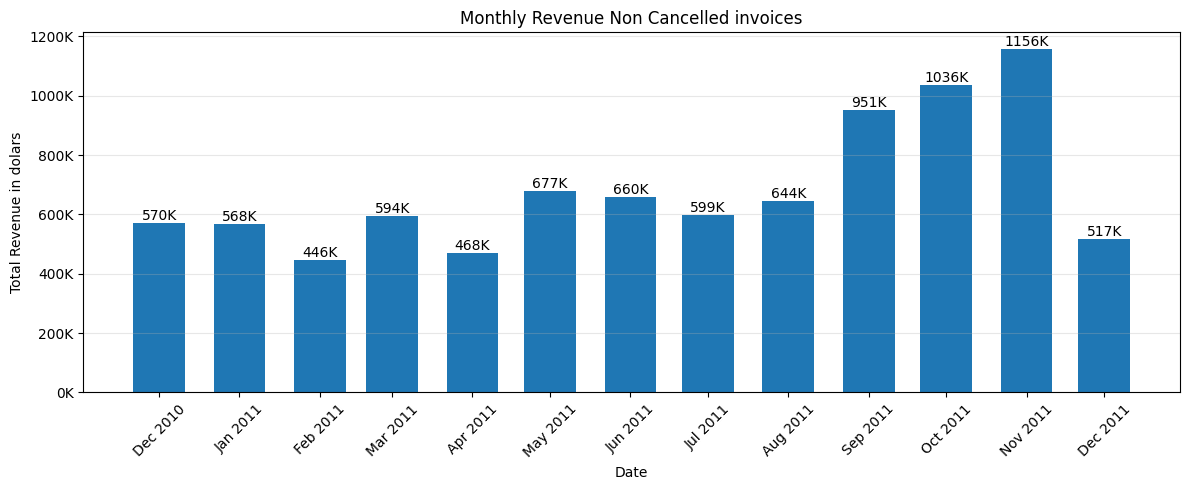

In [68]:
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(height=grouped_by_month_year['total_value'], x=grouped_by_month_year['year_month'].dt.to_timestamp(), width=20)



ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

ax.bar_label(bars, labels= [ f"{x/1_000:.0f}K" for x in grouped_by_month_year['total_value']])

plt.title('Monthly Revenue Non Cancelled invoices')
plt.xlabel('Date')
plt.ylabel('Total Revenue in dolars')

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()

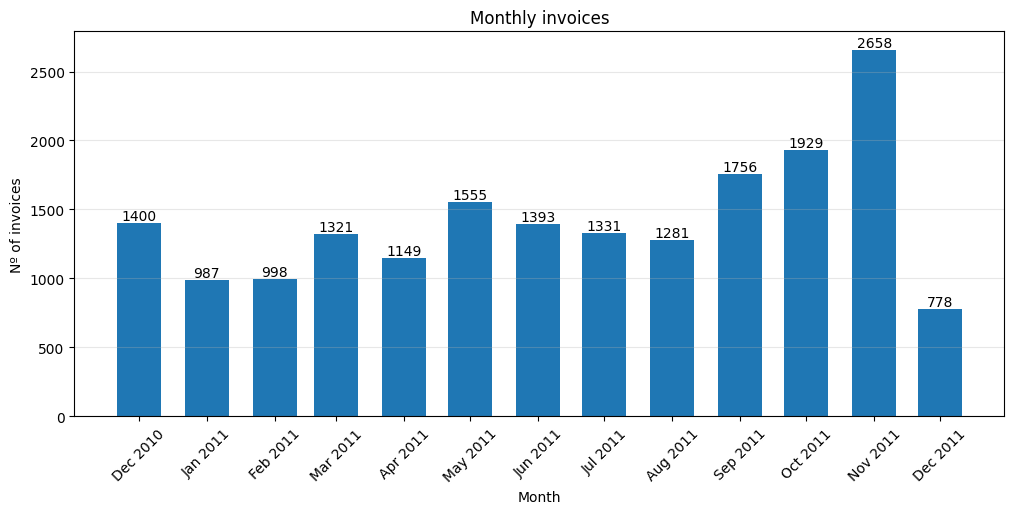

In [69]:
fig1, ax1 = plt.subplots(figsize = (12,5))
bars1 = ax1.bar(x = grouped_by_month_year['year_month'].dt.to_timestamp(), height=grouped_by_month_year['invoice_count'], width = 20)

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax1.bar_label(bars1, labels=[f"{x}" for x in grouped_by_month_year['invoice_count']])

plt.title('Monthly invoices')
plt.ylabel('Nº of invoices')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [70]:
grouped_by_month_year['average_invoice_value'] = grouped_by_month_year['total_value']/grouped_by_month_year['invoice_count']
grouped_by_month_year.head()

,year_month,total_value,invoice_count,average_invoice_value
0,2010-12,570422.730,1400,407.444807
1,2011-01,568101.310,987,575.583901
2,2011-02,446084.920,998,446.978878
3,2011-03,594081.760,1321,449.721241
4,2011-04,468374.331,1149,407.636493


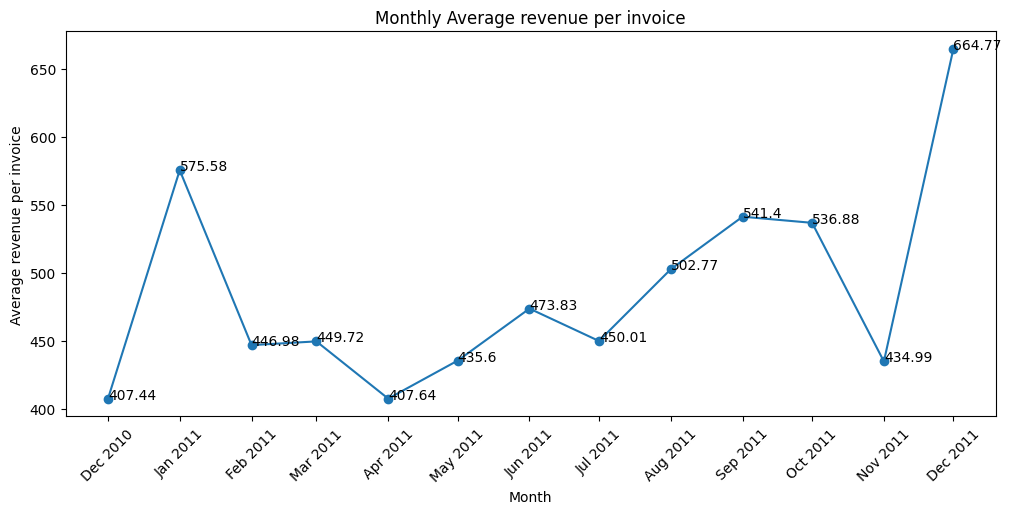

In [71]:
fig, ax = plt.subplots(figsize=(12,5))
line = ax.plot(grouped_by_month_year['year_month'].dt.to_timestamp(), grouped_by_month_year['average_invoice_value'], marker = 'o')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for x, y in zip(grouped_by_month_year['year_month'].dt.to_timestamp(), grouped_by_month_year['average_invoice_value']):
    ax.annotate(f'{round(y,2)}', (x,y))

plt.xticks(rotation=45)
plt.title('Monthly Average revenue per invoice')
plt.xlabel('Month')
plt.ylabel('Average revenue per invoice')
plt.show()

In [72]:
customer_level_df = (summary_df[summary_df['canceled'] == False].groupby(by='CustomerID')
                                .agg(
                                    total_revenue = ('total_value','sum'),
                                    number_of_invoices = ('InvoiceNo', 'count'),
                                    number_of_unique_products = ('num_products', 'sum')                                
                                    )).reset_index()

customer_level_df['average_invoice_value'] = customer_level_df.total_revenue / customer_level_df.number_of_invoices
customer_level_df['average_unique_products'] = customer_level_df.number_of_unique_products / customer_level_df.number_of_invoices

customer_level_df.head()

,CustomerID,total_revenue,number_of_invoices,number_of_unique_products,average_invoice_value,average_unique_products
0,12346.0,77183.60,1,1,77183.600000,1.00
1,12347.0,4310.00,7,182,615.714286,26.00
2,12348.0,1797.24,4,27,449.310000,6.75
3,12349.0,1757.55,1,73,1757.550000,73.00
4,12350.0,334.40,1,17,334.400000,17.00


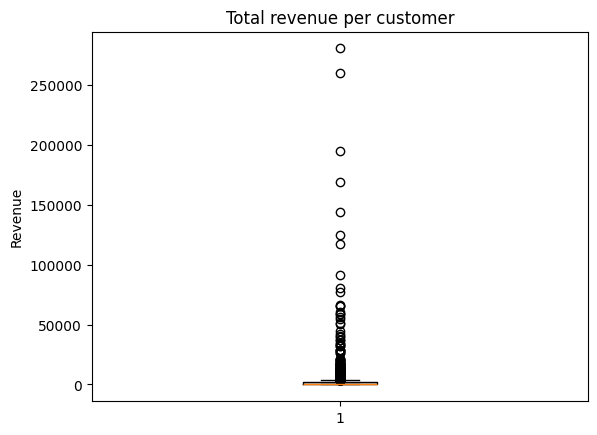

In [73]:
plt.boxplot(customer_level_df['total_revenue'])
plt.title('Total revenue per customer')
plt.ylabel('Revenue')
plt.show()


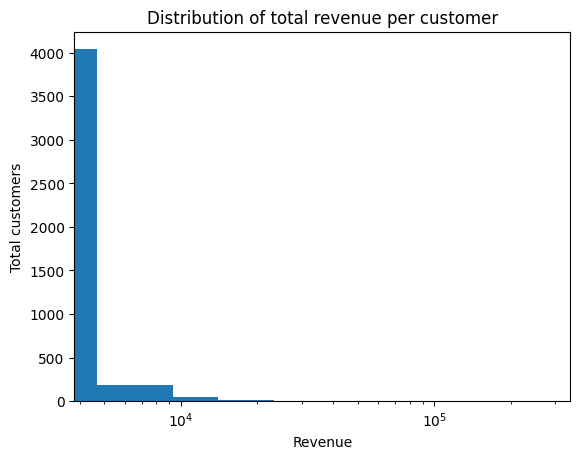

In [74]:
plt.hist(customer_level_df['total_revenue'], bins=60)
plt.xlabel('Revenue')
plt.ylabel('Total customers')
plt.title('Distribution of total revenue per customer')
plt.xscale('log')

In [81]:
threshold = customer_level_df['total_revenue'].quantile(0.95)
customer_level_df['over95'] = customer_level_df['total_revenue'] >= threshold
customer_level_df.head()

outlierscustomers = customer_level_df[customer_level_df['over95'] == True].total_revenue.sum()
standardcustomers = customer_level_df[customer_level_df['over95'] == False].total_revenue.sum()

df_revenue = pd.DataFrame({'outliers': outlierscustomers, 'standard' : standardcustomers }, index=['revenue'])

revenue_top_5 = (outlierscustomers / customer_level_df['total_revenue'].sum())*100

print('The top 5% of customers generate the ' + str(revenue_top_5.round(2)) +'% of total revenue')


df_revenue.head()

The top 5% of customers generate the 50.46% of total revenue


,outliers,standard
revenue,4484050.62,4403158.274
